<a href="https://colab.research.google.com/github/berkayagrdmr/TCSG-POYRAZ-Resistance-and-Propulsion-Analysis/blob/main/alansalgrafik.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

-------------------------------------------------------------------------------------------------------------------
V(kn)  | Fn      | CFx10³  | RF      | 1+k1   | Rv      | Rapp   | Rw      | Rb     | Rtr    | Ra     | RT      | PE      
-------------------------------------------------------------------------------------------------------------------
5.0    | 0.1186  | 2.0718  | 3.00    | 1.2710 | 3.82    | 0.00   | 0.00    | 0.000  | 3.152  | 0.94   | 7.91    | 20.3    
6.0    | 0.1423  | 2.0184  | 4.21    | 1.2710 | 5.35    | 0.00   | 0.03    | 0.000  | 4.319  | 1.35   | 11.05   | 34.1    
7.0    | 0.1660  | 1.9748  | 5.61    | 1.2710 | 7.13    | 0.00   | 0.16    | 0.000  | 5.580  | 1.84   | 14.70   | 52.9    
8.0    | 0.1897  | 1.9381  | 7.19    | 1.2710 | 9.14    | 0.00   | 0.55    | 0.000  | 6.898  | 2.40   | 18.99   | 78.1    
9.0    | 0.2134  | 1.9066  | 8.95    | 1.2710 | 11.38   | 0.00   | 1.49    | 0.000  | 8.236  | 3.04   | 24.14   | 111.8   
10.0   | 0.2371  | 1.8791  | 1

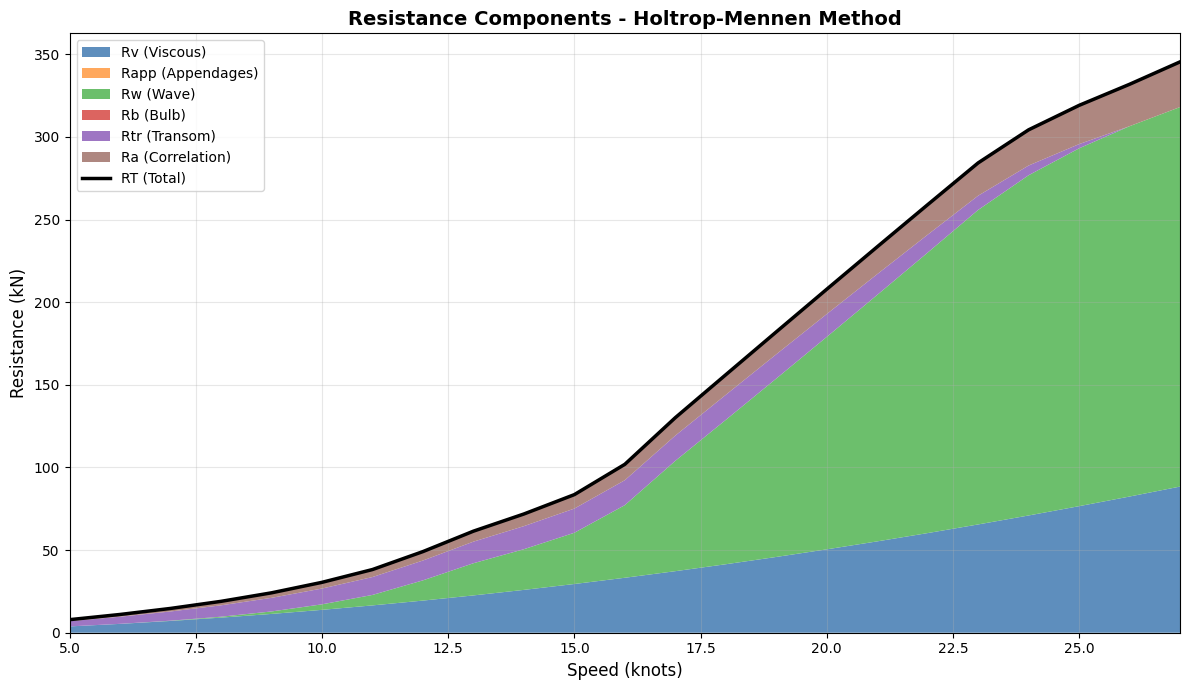

In [ ]:
import math
import matplotlib.pyplot as plt

# ==============================================================================
# 1. YENI TASARIM PARAMETRELERI
# ==============================================================================
L       = 48     # Su hatti boyu (m)
B       = 9.0      # Kalip genisligi (m)
T_F     = 2.5      # Bas draft (m)
T_A     = 2.5      # Kic draft (m)
disp    = 470.75   # Deplasman hacmi (m^3)
C_B     = 0.48     # Blok katsayisi
C_P     = 0.659    # Prizmatik katsayi
C_M     = 0.746    # Orta kesit katsayisi
C_WP    = 0.803    # Su hatti alan katsayisi
lcb     = -2.24   # Yuzdurme merkezi boyuna konumu (L'nin %'si olarak)
A_T     = 5.772    # Batan transom alani
A_BT    = 0.0      # Bodoslama enkesit alani
h_B     = 1.5      # Bodoslama alani merkezinin yuksekligi
C_stern = 0.0      # Kic form katsayisi
S_APP   = 0.0      # Ek takilarin islak alani (m^2)
k2_eq   = 1.5      # Esdeger ek taki direnc faktoru (1+k2)
i_E     = None     # Yarim giris acisi (derece)

# ==============================================================================
# 2. HOLTROP & MENNEN HESAPLAMA FONKSIYONU
# ==============================================================================
def calculate_holtrop_mennen(V_knots, L, B, T_F, T_A, disp, C_B, C_P, C_M, C_WP, lcb, A_T, A_BT, h_B, C_stern, S_APP, k2_eq, i_E):
    V = V_knots * 0.51444
    g = 9.80665
    rho = 1025.0
    nu = 1.18831e-6
    T = (T_F + T_A) / 2.0

    F_n = V / math.sqrt(g * L)

    term_S1 = 0.453 + 0.4425 * C_B - 0.2862 * C_M - 0.003467 * (B / T) + 0.3696 * C_WP
    term_S2 = 2.38 * A_BT / C_B if C_B != 0 else 0
    S = L * (2 * T + B) * math.sqrt(C_M) * term_S1 + term_S2

    Re = V * L / nu
    C_F = 0.075 / (math.log10(Re) - 2)**2
    R_F = 0.5 * rho * V**2 * S * C_F

    L_R = L * (1 - C_P + 0.06 * C_P * lcb / (4 * C_P - 1))
    c_14 = 1 + 0.011 * C_stern
    term_k1 = 0.487118 * c_14 * (B / L)**1.06806 * (T / L)**0.46106 * (L / L_R)**0.121563 * (L**3 / disp)**0.36486 * (1 - C_P)**-0.604247
    one_plus_k1 = 0.93 + term_k1

    R_V = R_F * one_plus_k1
    R_APP = 0.5 * rho * V**2 * S_APP * k2_eq * C_F

    if A_BT > 0:
        c_3 = 0.56 * A_BT**1.5 / (B * T * (0.31 * math.sqrt(A_BT) + T_F - h_B))
    else:
        c_3 = 0.0

    c_2 = math.exp(-1.89 * math.sqrt(c_3))
    c_5 = 1 - 0.8 * A_T / (B * T * C_M) if A_T > 0 else 1.0
    d = -0.9

    if L / B < 12:
        lamb = 1.446 * C_P - 0.03 * (L / B)
    else:
        lamb = 1.446 * C_P - 0.36

    disp_ratio = L**3 / disp
    if disp_ratio < 512:
        c_15 = -1.69385
    elif 512 <= disp_ratio <= 1726.91:
        c_15 = -1.69385 + (L / (disp**(1/3)) - 8.0) / 2.36
    else:
        c_15 = 0.0

    m_4 = c_15 * 0.4 * math.exp(-0.034 * F_n**-3.29)

    if i_E is None:
        term_iE = -(L / B)**0.80856 * (1 - C_WP)**0.30484 * (1 - C_P - 0.0225 * lcb)**0.6367 * (L_R / B)**0.34574 * (100 * disp / L**3)**0.16302
        i_E = 1 + 89 * math.exp(term_iE)

    def calculate_R_W_A(Fn_val):
        if B / L < 0.11:
            c_7 = 0.229577 * (B / L)**0.33333
        elif 0.11 <= B / L <= 0.25:
            c_7 = B / L
        else:
            c_7 = 0.5 - 0.0625 * (L / B)
        c_1 = 2223105 * c_7**3.78613 * (T / B)**1.07961 * (90 - i_E)**-1.37565
        if C_P < 0.8:
            c_16 = 8.07981 * C_P - 13.8673 * C_P**2 + 6.984388 * C_P**3
        else:
            c_16 = 1.73014 - 0.7067 * C_P
        m_1 = 0.0140407 * (L / T) - 1.75254 * (disp**(1/3) / L) - 4.79323 * (B / L) - c_16
        m_4_local = c_15 * 0.4 * math.exp(-0.034 * Fn_val**-3.29)
        return c_1 * c_2 * c_5 * disp * rho * g * math.exp(m_1 * Fn_val**d + m_4_local * math.cos(lamb * Fn_val**-2))

    def calculate_R_W_B(Fn_val):
        c_17 = 6919.3 * C_M**-1.3346 * (disp / L**3)**2.00977 * (L / B - 2)**1.40692
        m_3 = -7.2035 * (B / L)**0.326869 * (T / B)**0.605375
        m_4_local = c_15 * 0.4 * math.exp(-0.034 * Fn_val**-3.29)
        return c_17 * c_2 * c_5 * disp * rho * g * math.exp(m_3 * Fn_val**d + m_4_local * math.cos(lamb * Fn_val**-2))

    if F_n <= 0.40:
        R_W = calculate_R_W_A(F_n)
    elif F_n >= 0.55:
        R_W = calculate_R_W_B(F_n)
    else:
        R_W_A_04 = calculate_R_W_A(0.40)
        R_W_B_055 = calculate_R_W_B(0.55)
        R_W = R_W_A_04 + (10 * F_n - 4) * (R_W_B_055 - R_W_A_04) / 1.5

    if A_BT > 0:
        P_B = 0.56 * math.sqrt(A_BT) / (T_F - 1.5 * h_B)
        F_ni = V / math.sqrt(g * (T_F - h_B - 0.25 * math.sqrt(A_BT)) + 0.15 * V**2)
        R_B = 0.11 * math.exp(-3 * P_B**-2) * F_ni**3 * A_BT**1.5 * rho * g / (1 + F_ni**2)
    else:
        R_B = 0.0

    if A_T > 0:
        F_nT = V / math.sqrt(2 * g * A_T / (B + B * C_WP))
        if F_nT < 5:
            c_6 = 0.2 * (1 - 0.2 * F_nT)
        else:
            c_6 = 0.0
        R_TR = 0.5 * rho * V**2 * A_T * c_6
    else:
        R_TR = 0.0

    if T_F / L <= 0.04:
        c_4 = T_F / L
    else:
        c_4 = 0.04

    C_A = 0.006 * (L + 100)**-0.16 - 0.00205 + 0.003 * math.sqrt(L / 7.5) * C_B**4 * c_2 * (0.04 - c_4)
    R_A = 0.5 * rho * V**2 * S * C_A

    R_total = R_V + R_APP + R_W + R_B + R_TR + R_A
    PE = (R_total / 1000) * V

    return {
        "Fn": F_n,
        "CFx10^3": C_F * 1000,
        "RF": R_F / 1000,
        "1+k1": one_plus_k1,
        "Rv": R_V / 1000,
        "Rapp": R_APP / 1000,
        "Rw": R_W / 1000,
        "Rb": R_B / 1000,
        "Rtr": R_TR / 1000,
        "Ra": R_A / 1000,
        "RT": R_total / 1000,
        "PE": PE
    }

# ==============================================================================
# 3. TABLO VE YIGILMIS ALAN (STACKED AREA) GRAFIGI
# ==============================================================================
hizlar = range(5, 28)
rv_list, rapp_list, rw_list, rb_list, rtr_list, ra_list, rt_list = [], [], [], [], [], [], []

print("-" * 115)
print(f"{'V(kn)':<6} | {'Fn':<7} | {'CFx10³':<7} | {'RF':<7} | {'1+k1':<6} | {'Rv':<7} | {'Rapp':<6} | {'Rw':<7} | {'Rb':<6} | {'Rtr':<6} | {'Ra':<6} | {'RT':<7} | {'PE':<8}")
print("-" * 115)

for v in hizlar:
    res = calculate_holtrop_mennen(v, L, B, T_F, T_A, disp, C_B, C_P, C_M, C_WP, lcb, A_T, A_BT, h_B, C_stern, S_APP, k2_eq, i_E)

    rv_list.append(res["Rv"])
    rapp_list.append(res["Rapp"])
    rw_list.append(res["Rw"])
    rb_list.append(res["Rb"])
    rtr_list.append(res["Rtr"])
    ra_list.append(res["Ra"])
    rt_list.append(res["RT"])

    print(f"{v:<6.1f} | {res['Fn']:<7.4f} | {res['CFx10^3']:<7.4f} | {res['RF']:<7.2f} | {res['1+k1']:<6.4f} | {res['Rv']:<7.2f} | {res['Rapp']:<6.2f} | {res['Rw']:<7.2f} | {res['Rb']:<6.3f} | {res['Rtr']:<6.3f} | {res['Ra']:<6.2f} | {res['RT']:<7.2f} | {res['PE']:<8.1f}")

print("-" * 115)

# Grafik Çizimi (Stacked Area)
plt.figure(figsize=(12, 7))

# Renkleri arkadasinizin raporundakine benzer ayarladik
colors = ['#4c82b6', '#ff9f4b', '#5cb85c', '#d9534f', '#9467bd', '#a57a72']
labels = ['Rv (Viscous)', 'Rapp (Appendages)', 'Rw (Wave)', 'Rb (Bulb)', 'Rtr (Transom)', 'Ra (Correlation)']

# Yığılmış alan (Stacked Area)
plt.stackplot(hizlar, rv_list, rapp_list, rw_list, rb_list, rtr_list, ra_list, labels=labels, colors=colors, alpha=0.9)

# Toplam Direnc (Siyah cizgi)
plt.plot(hizlar, rt_list, color='black', linewidth=2.5, label='RT (Total)')

plt.title('Resistance Components - Holtrop-Mennen Method', fontsize=14, fontweight='bold')
plt.xlabel('Speed (knots)', fontsize=12)
plt.ylabel('Resistance (kN)', fontsize=12)
plt.xlim(min(hizlar), max(hizlar))
plt.grid(True, linestyle='-', alpha=0.3)
plt.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()